# Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms

**Name:** Abhilash Reddy Marthala 
**Course:** MSCS 634 – Advanced Big Data and Data Mining  
**Assignment:** Lab 3

## Objective

Apply K-Means and K-Medoids clustering to the Wine dataset,
evaluate the results using Silhouette Score and Adjusted Rand Index,
and compare the clusters through visualizations.

In [1]:
import pandas as pd
from sklearn.datasets import load_wine

# Load the dataset
wine = load_wine()

# Create a table of features
df = pd.DataFrame(wine.data, columns=wine.feature_names)

print("Dataset shape:", df.shape)
print("\nFeature names:")
print(wine.feature_names)

print("\nFirst five rows:")
display(df.head())

print("\nMissing values:", df.isna().sum().sum())

print("\nClass distribution:")
class_counts = pd.Series(wine.target).value_counts().sort_index()
class_counts.index = wine.target_names
display(class_counts.rename("Number of samples"))

print("\nSummary statistics:")
display(df.describe())

Dataset shape: (178, 13)

Feature names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

First five rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Missing values: 0

Class distribution:


class_0    59
class_1    71
class_2    48
Name: Number of samples, dtype: int64


Summary statistics:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [2]:
from sklearn.preprocessing import StandardScaler

# Standardize all 13 features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Keep actual class labels for evaluation later
y_true = wine.target

scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

print("First five standardized rows:")
display(scaled_df.head())

print("\nFeature means (approximately 0):")
print(scaled_df.mean().round(3))

print("\nFeature standard deviations (approximately 1):")
print(scaled_df.std(ddof=0).round(3))

First five standardized rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874



Feature means (approximately 0):
alcohol                        -0.0
malic_acid                     -0.0
ash                            -0.0
alcalinity_of_ash              -0.0
magnesium                      -0.0
total_phenols                   0.0
flavanoids                     -0.0
nonflavanoid_phenols            0.0
proanthocyanins                -0.0
color_intensity                 0.0
hue                             0.0
od280/od315_of_diluted_wines    0.0
proline                        -0.0
dtype: float64

Feature standard deviations (approximately 1):
alcohol                         1.0
malic_acid                      1.0
ash                             1.0
alcalinity_of_ash               1.0
magnesium                       1.0
total_phenols                   1.0
flavanoids                      1.0
nonflavanoid_phenols            1.0
proanthocyanins                 1.0
color_intensity                 1.0
hue                             1.0
od280/od315_of_diluted_wines    1.0
pro

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Fit K-Means using all 13 standardized features
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Calculate evaluation metrics
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y_true, kmeans_labels)

print("K-Means Results")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Adjusted Rand Index (ARI): {kmeans_ari:.4f}")

print("\nSamples in each cluster:")
display(
    pd.Series(kmeans_labels)
    .value_counts()
    .sort_index()
    .rename("Number of samples")
)

K-Means Results
Silhouette Score: 0.2849
Adjusted Rand Index (ARI): 0.8975

Samples in each cluster:


C:\Users\abhil\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


0    65
1    51
2    62
Name: Number of samples, dtype: int64

In [5]:
import numpy as np
from sklearn.metrics import pairwise_distances

def pam_kmedoids(X, k=3, random_state=42):
    """K-Medoids using PAM: repeatedly swap medoids to reduce total distance."""
    distances = pairwise_distances(X, metric="euclidean")
    rng = np.random.default_rng(random_state)

    # Medoids are indices of actual observations
    medoids = rng.choice(len(X), size=k, replace=False)
    cost = distances[:, medoids].min(axis=1).sum()

    while True:
        best_cost = cost
        best_medoids = medoids.copy()

        # Evaluate every swap between a medoid and a non-medoid
        non_medoids = np.setdiff1d(np.arange(len(X)), medoids)

        for position in range(k):
            for candidate in non_medoids:
                trial = medoids.copy()
                trial[position] = candidate
                trial_cost = distances[:, trial].min(axis=1).sum()

                if trial_cost < best_cost - 1e-10:
                    best_cost = trial_cost
                    best_medoids = trial.copy()

        # Stop when no swap improves the objective
        if best_cost >= cost - 1e-10:
            break

        medoids = best_medoids
        cost = best_cost

    labels = distances[:, medoids].argmin(axis=1)
    return labels, medoids

# Fit using all 13 standardized features
kmedoids_labels, medoid_indices = pam_kmedoids(X_scaled)
kmedoids_centers = X_scaled[medoid_indices]

# Calculate evaluation metrics
kmedoids_silhouette = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y_true, kmedoids_labels)

print("K-Medoids Results (PAM implementation)")
print(f"Silhouette Score: {kmedoids_silhouette:.4f}")
print(f"Adjusted Rand Index (ARI): {kmedoids_ari:.4f}")
print("Medoid row indices:", medoid_indices)

print("\nSamples in each cluster:")
display(
    pd.Series(kmedoids_labels)
    .value_counts()
    .sort_index()
    .rename("Number of samples")
)

K-Medoids Results (PAM implementation)
Silhouette Score: 0.2676
Adjusted Rand Index (ARI): 0.7411
Medoid row indices: [106  35 148]

Samples in each cluster:


0    55
1    74
2    49
Name: Number of samples, dtype: int64

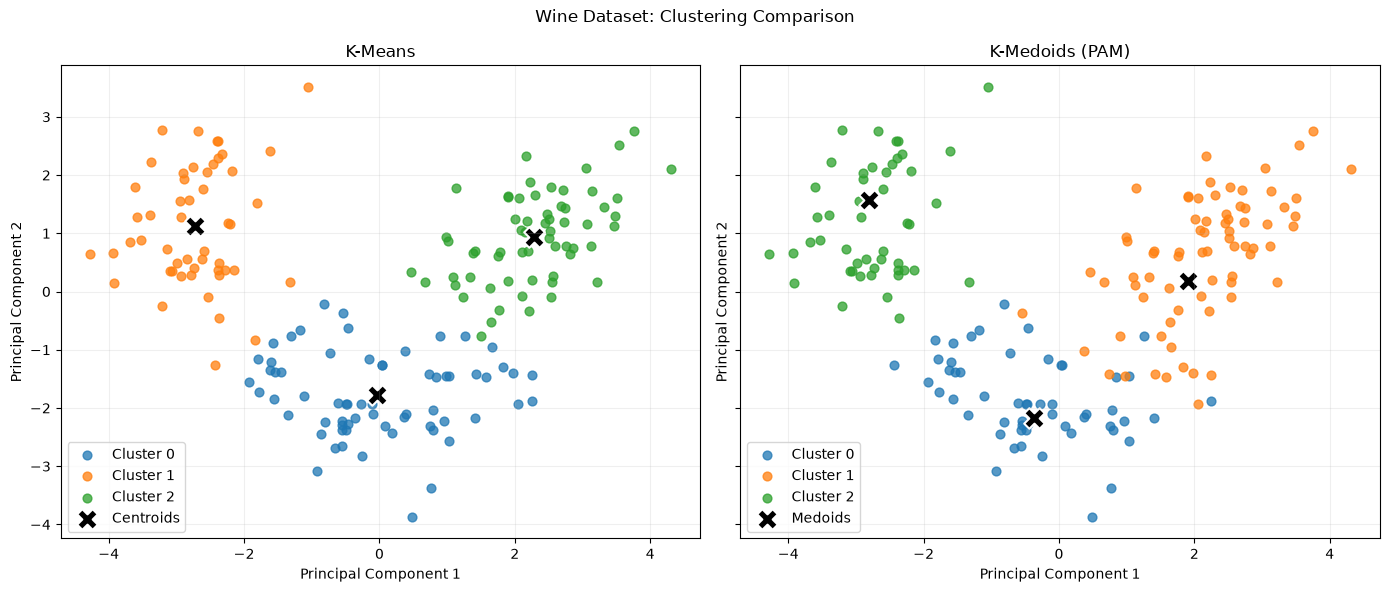

Variance represented in the 2D plots: 55.4%


,Algorithm,Silhouette Score,Adjusted Rand Index
0,K-Means,0.2849,0.8975
1,K-Medoids (PAM),0.2676,0.7411


In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Create a shared 2D projection for both plots
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Project the centroids and medoids into the same coordinates
kmeans_centers_pca = pca.transform(kmeans.cluster_centers_)
kmedoids_centers_pca = pca.transform(kmedoids_centers)

fig, axes = plt.subplots(
    1, 2, figsize=(14, 6), sharex=True, sharey=True
)

plot_data = [
    (axes[0], kmeans_labels, kmeans_centers_pca,
     "K-Means", "Centroids"),
    (axes[1], kmedoids_labels, kmedoids_centers_pca,
     "K-Medoids (PAM)", "Medoids")
]

for ax, labels, centers, title, center_label in plot_data:
    for cluster in range(3):
        points = X_pca[labels == cluster]
        ax.scatter(
            points[:, 0], points[:, 1],
            s=40, alpha=0.75, label=f"Cluster {cluster}"
        )

    ax.scatter(
        centers[:, 0], centers[:, 1],
        marker="X", s=220, color="black",
        edgecolor="white", linewidth=1.5,
        label=center_label
    )

    ax.set_title(title)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.legend()
    ax.grid(alpha=0.2)

plt.suptitle("Wine Dataset: Clustering Comparison")
plt.tight_layout()
plt.show()

print(
    "Variance represented in the 2D plots: "
    f"{pca.explained_variance_ratio_.sum():.1%}"
)

# Compare metrics calculated in the original standardized feature space
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "K-Medoids (PAM)"],
    "Silhouette Score": [kmeans_silhouette, kmedoids_silhouette],
    "Adjusted Rand Index": [kmeans_ari, kmedoids_ari]
})

display(comparison.round(4))

## Results and Analysis

| Algorithm | Silhouette Score | Adjusted Rand Index |
|---|---:|---:|
| K-Means | 0.2849 | 0.8975 |
| K-Medoids (PAM) | 0.2676 | 0.7411 |

### Which algorithm produced better-defined clusters?

K-Means achieved a slightly higher Silhouette Score (0.2849)
than K-Medoids (0.2676), indicating somewhat more compact and
better-separated clusters. Both scores suggest that cluster
separation is moderate rather than strong.

K-Means also achieved a higher ARI (0.8975 versus 0.7411),
showing closer agreement with the actual wine classes.
The actual class labels were used only for evaluation.

### Cluster positioning and visualization

K-Means centers are averages of the observations assigned to
each cluster, whereas K-Medoids centers are actual observations.
This difference can shift center positions and change assignments
of points near cluster boundaries.

The side-by-side plots show a shared PCA projection representing
55.4% of the total variance. Some information is therefore omitted,
and apparent overlap or shape in two dimensions may not reflect
the full 13-dimensional structure. Both algorithms were trained
and evaluated using all 13 standardized features.

### When each algorithm may be preferable

K-Means is generally preferable for larger numerical datasets
with compact clusters when computational efficiency is important.
Its use of squared distances makes it sensitive to extreme values.

K-Medoids may be preferable when representative observations
are needed as centers or when greater resistance to outliers is
important. It can also work with suitable alternative distance
measures. The exhaustive PAM swap implementation used here is
more computationally expensive than K-Means.

### Challenges and decisions

The scikit-learn-extra installation failed because compiling
the package required Microsoft C++ Build Tools. A custom PAM
K-Medoids implementation using NumPy and scikit-learn distance
calculations was used instead.

Features were standardized using z-score normalization.
Both algorithms used k = 3 and random_state = 42.
K-Means used 10 initializations; PAM used one random initialization.
These results describe this run and may vary with initialization.